# Payment behavior and fraud: one dataset, two models

## tl;dr

On the same 128 held-out synthetic invoices, the supplied **SAP-RPT-1.6 Playground table export** has **70.3% late-payment accuracy** versus **65.6% for XGBoost**. For fraud, RPT has **92.2% accuracy** versus **90.6%**, but RPT finds **0 of 8** fraud-labelled invoices while XGBoost finds **2 of 8**. Read fraud recall alongside accuracy because fraud is rare.

The export contains filled labels for the 128 test rows but no model metadata, probabilities, or uncertainty values. We treat those filled labels as RPT predictions based on the supplied export's provenance; this notebook cannot independently verify which model produced them. RPT ROC AUC is unavailable.

Sources: `data/synthetic_invoices/payment_behavior.csv` (ground truth), `data/synthetic_invoices/exports/rpt_playground_export.csv` (copy of supplied `table-data.csv`), and `scripts/run_xgboost_invoices.py` (XGBoost baseline).

## Context & methods

The source file contains 1,152 synthetic invoices in a fixed order. The first 1,024 are XGBoost training rows and RPT context rows; the final 128 are the shared test rows. Both targets are binary (`paid_late`, `is_fraud`). XGBoost excludes invoice IDs from model features. The RPT upload replaces both test targets with `[PREDICT]`.

### Key assumptions

- The supplied Playground table export is the output of the RPT run. Its context labels match the source, its feature values and invoice IDs match throughout, and its test labels are interpreted as predictions.
- Labels are generated from a known noisy formula and do not represent actual customer behavior or fraud.
- The split is fixed and is not a time-based forecast or an external validation set.
- Only eight test invoices have the fraud label, so fraud metrics are sensitive to a few predictions.
- The export has class labels only. It does not support an RPT ROC AUC or probability calibration comparison.

### 1. Load the shared dataset

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from IPython.display import display, Markdown

ROOT = next(path for path in (Path.cwd(), Path.cwd().parent) if (path / "data/synthetic_invoices/payment_behavior.csv").exists())
sys.path.insert(0, str(ROOT / "scripts"))
from generate_synthetic_invoices import CONTEXT_ROWS, PREDICTION_ROWS, TARGETS
from run_xgboost_invoices import load_split, train_models, predict_frame

DATA = ROOT / "data/synthetic_invoices"
invoices = pd.read_csv(DATA / "payment_behavior.csv")
train, test = load_split()
print(f"Shared input: {len(invoices)} invoices | train/context: {len(train)} | test: {len(test)}")
display(invoices.head(5))

Shared input: 1152 invoices | train/context: 1024 | test: 128


,invoice_id,invoice_amount_eur,payment_terms_days,customer_tenure_months,prior_late_payment_rate,open_invoice_count,customer_segment,region,billing_address_mismatch,bank_account_changed_recently,weekend_submission,paid_late,is_fraud
0,SYN-00001,3606.34,60,90,0.183,9,small,Nordics,0,0,1,0,0
1,SYN-00002,807.59,14,66,0.244,2,small,Southern Europe,0,0,0,0,0
2,SYN-00003,928.52,30,7,0.586,0,midmarket,Southern Europe,0,0,1,1,0
3,SYN-00004,2994.31,14,31,0.094,7,enterprise,Nordics,0,0,0,0,0
4,SYN-00005,2112.90,14,17,0.133,5,midmarket,DACH,0,0,1,0,0


### 2. Check the fair comparison split

In [2]:
rpt_csv = DATA / "exports/rpt_upload.csv"
rpt_input = pd.read_csv(rpt_csv, dtype={target: str for target in TARGETS})
assert len(invoices) == len(rpt_input) == CONTEXT_ROWS + PREDICTION_ROWS
assert invoices.invoice_id.is_unique
assert rpt_input.drop(columns=list(TARGETS)).equals(invoices.drop(columns=list(TARGETS)))
for target in TARGETS:
    assert rpt_input[target].iloc[:CONTEXT_ROWS].astype(int).equals(train[target])
    assert rpt_input[target].iloc[CONTEXT_ROWS:].eq("[PREDICT]").all()
print("Both model inputs have identical invoice IDs and predictors; RPT test targets are hidden.")
class_counts = pd.DataFrame({target: [int(train[target].sum()), int(test[target].sum())] for target in TARGETS}, index=["Training/context", "Test"])
display(class_counts)

Both model inputs have identical invoice IDs and predictors; RPT test targets are hidden.


,paid_late,is_fraud
Training/context,450,53
Test,51,8


### 3. Inspect target balance

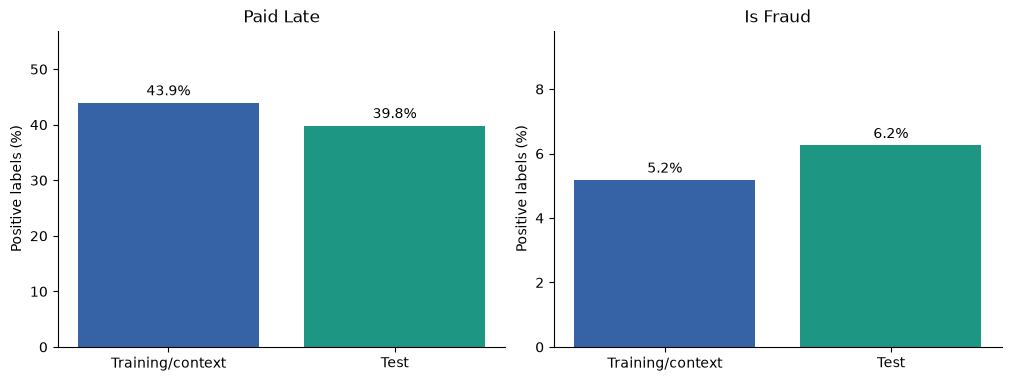

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), constrained_layout=True)
for ax, target in zip(axes, TARGETS):
    values = [train[target].mean() * 100, test[target].mean() * 100]
    bars = ax.bar(["Training/context", "Test"], values, color=["#3563a6", "#1d9683"])
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_ylim(0, max(values) * 1.25 + 2)
    ax.set_ylabel("Positive labels (%)")
    ax.set_title(target.replace("_", " ").title())
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

The fraud class is rare in both splits; accuracy by itself can hide missed fraud cases. The positive case counts above are the denominators for recall.

### 4. Fit XGBoost and score the held-out invoices

In [4]:
models, feature_columns = train_models(train)
xgb_results = predict_frame(models, feature_columns, test)
assert xgb_results.invoice_id.tolist() == test.invoice_id.tolist()
rows = []
for target in TARGETS:
    y = xgb_results[f"actual_{target}"]
    predicted = xgb_results[f"predicted_{target}"]
    probability = xgb_results[f"probability_{target}"]
    rows.append({"Model": "XGBoost", "Target": target, "Positive cases": int(y.sum()),
                 "Accuracy": accuracy_score(y, predicted),
                 "Precision": precision_score(y, predicted, zero_division=0),
                 "Recall": recall_score(y, predicted, zero_division=0),
                 "ROC AUC": roc_auc_score(y, probability)})
xgb_metrics = pd.DataFrame(rows).set_index(["Model", "Target"])
display(xgb_metrics.round(3))
display(xgb_results[["invoice_id", "actual_paid_late", "predicted_paid_late", "probability_paid_late", "actual_is_fraud", "predicted_is_fraud", "probability_is_fraud"]].head(8).round(3))

Positive cases  Accuracy  Precision  Recall  ROC AUC
Model   Target                                                         
XGBoost paid_late              51     0.656      0.561   0.627    0.724
        is_fraud                8     0.906      0.250   0.250    0.699

,invoice_id,actual_paid_late,predicted_paid_late,probability_paid_late,actual_is_fraud,predicted_is_fraud,probability_is_fraud
1024,SYN-01025,1,0,0.379,0,0,0.060
1025,SYN-01026,0,0,0.347,1,0,0.311
1026,SYN-01027,0,0,0.437,0,0,0.114
1027,SYN-01028,0,0,0.433,0,0,0.035
1028,SYN-01029,1,0,0.312,0,0,0.100
1029,SYN-01030,0,0,0.123,0,0,0.064
1030,SYN-01031,0,0,0.459,0,0,0.264
1031,SYN-01032,0,0,0.047,0,0,0.053


### Screenshot this cell: XGBoost prediction results

The figure directly below combines the held-out metrics and five real predictions from the synthetic test set. Capture **this figure** for your presentation. The identical image is also saved as `notebooks/xgboost_prediction_results.png`.

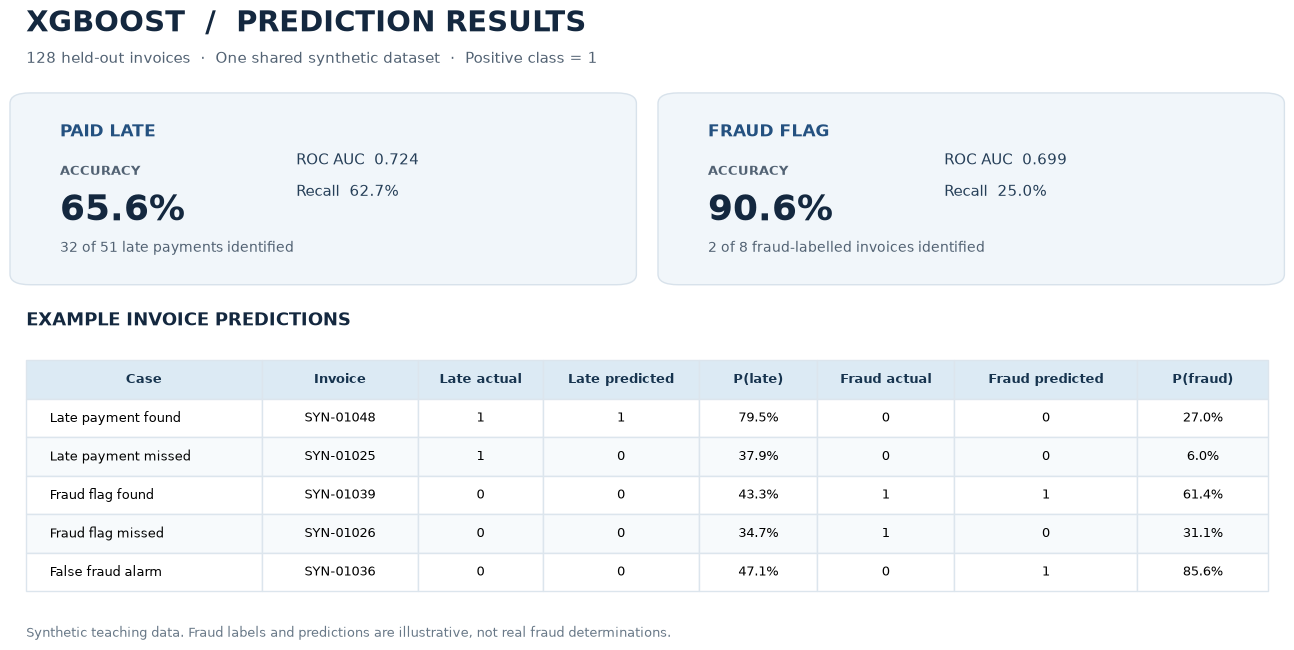

In [5]:
from matplotlib.patches import FancyBboxPatch

# Select examples that show successes and errors for both targets.
case_filters = [
    ("Late payment found", (xgb_results.actual_paid_late == 1) & (xgb_results.predicted_paid_late == 1)),
    ("Late payment missed", (xgb_results.actual_paid_late == 1) & (xgb_results.predicted_paid_late == 0)),
    ("Fraud flag found", (xgb_results.actual_is_fraud == 1) & (xgb_results.predicted_is_fraud == 1)),
    ("Fraud flag missed", (xgb_results.actual_is_fraud == 1) & (xgb_results.predicted_is_fraud == 0)),
    ("False fraud alarm", (xgb_results.actual_is_fraud == 0) & (xgb_results.predicted_is_fraud == 1)),
]
examples = []
used_ids = set()
for label, condition in case_filters:
    for _, row in xgb_results.loc[condition].iterrows():
        if row.invoice_id not in used_ids:
            examples.append((label, row))
            used_ids.add(row.invoice_id)
            break
assert len(examples) == len(case_filters)

fig = plt.figure(figsize=(13.5, 7.0), facecolor="white")
fig.text(0.04, 0.94, "XGBOOST  /  PREDICTION RESULTS", fontsize=21, fontweight="bold", color="#14283f")
fig.text(0.04, 0.895, "128 held-out invoices  ·  One shared synthetic dataset  ·  Positive class = 1", fontsize=11, color="#526273")

for left, title, target, detail in [
    (0.04, "PAID LATE", "paid_late", "32 of 51 late payments identified"),
    (0.52, "FRAUD FLAG", "is_fraud", "2 of 8 fraud-labelled invoices identified"),
]:
    fig.patches.append(FancyBboxPatch((left, 0.59), 0.44, 0.25, boxstyle="round,pad=0.012,rounding_size=0.015",
                                      transform=fig.transFigure, facecolor="#f1f6fa", edgecolor="#d8e2eb"))
    row = xgb_metrics.loc[("XGBoost", target)]
    fig.text(left+0.025, 0.79, title, fontsize=12, fontweight="bold", color="#245180")
    fig.text(left+0.025, 0.735, "ACCURACY", fontsize=9, fontweight="bold", color="#526273")
    fig.text(left+0.025, 0.67, f"{row['Accuracy']:.1%}", fontsize=26, fontweight="bold", color="#14283f")
    fig.text(left+0.20, 0.75, f"ROC AUC  {row['ROC AUC']:.3f}", fontsize=11, color="#263f58")
    fig.text(left+0.20, 0.705, f"Recall  {row['Recall']:.1%}", fontsize=11, color="#263f58")
    fig.text(left+0.025, 0.625, detail, fontsize=10, color="#526273")

fig.text(0.04, 0.52, "EXAMPLE INVOICE PREDICTIONS", fontsize=13, fontweight="bold", color="#14283f")
headers = ["Case", "Invoice", "Late actual", "Late predicted", "P(late)", "Fraud actual", "Fraud predicted", "P(fraud)"]
table_rows = [[label, row.invoice_id, int(row.actual_paid_late), int(row.predicted_paid_late),
               f"{row.probability_paid_late:.1%}", int(row.actual_is_fraud), int(row.predicted_is_fraud),
               f"{row.probability_is_fraud:.1%}"] for label, row in examples]
ax = fig.add_axes([0.04, 0.14, 0.92, 0.33])
ax.axis("off")
table = ax.table(cellText=table_rows, colLabels=headers, loc="center", cellLoc="center", bbox=[0, 0, 1, 1],
                 colWidths=[0.18, 0.12, 0.095, 0.12, 0.09, 0.105, 0.14, 0.10])
table.auto_set_font_size(False)
table.set_fontsize(9.5)
for (row_index, column_index), cell in table.get_celld().items():
    cell.set_edgecolor("#dce5ed")
    if row_index == 0:
        cell.set_facecolor("#dceaf4")
        cell.set_text_props(weight="bold", color="#17344f")
    else:
        cell.set_facecolor("#ffffff" if row_index % 2 else "#f7fafc")
        if column_index == 0:
            cell.set_text_props(ha="left")
fig.text(0.04, 0.075, "Synthetic teaching data. Fraud labels and predictions are illustrative, not real fraud determinations.", fontsize=9.5, color="#687887")
fig.savefig(ROOT / "notebooks/xgboost_prediction_results.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

### XGBoost fraud prediction — run this cell

This cell uses the trained **fraud model** to predict `is_fraud` for the 128 held-out invoices. The table lists every invoice it flags as fraud (`1`).

In [6]:
from run_xgboost_invoices import encode_features

fraud_features = encode_features(test, feature_columns)
fraud_probabilities = models["is_fraud"].predict_proba(fraud_features)[:, 1]
fraud_predicted = (fraud_probabilities >= 0.5).astype(int)
assert (fraud_predicted == xgb_results["predicted_is_fraud"].to_numpy()).all()
fraud_cases = pd.DataFrame({
    "invoice_id": test["invoice_id"].to_numpy(),
    "actual_is_fraud": test["is_fraud"].to_numpy(),
    "predicted_is_fraud": fraud_predicted,
    "fraud_probability": fraud_probabilities,
})
flagged_fraud = fraud_cases[fraud_cases["predicted_is_fraud"] == 1]
print(f"XGBoost flagged {len(flagged_fraud)} of {len(fraud_cases)} test invoices as fraud.")
print(f"Correct fraud flags: {int(flagged_fraud['actual_is_fraud'].sum())}")
display(flagged_fraud.round({"fraud_probability": 3}))

XGBoost flagged 8 of 128 test invoices as fraud.
Correct fraud flags: 2


,invoice_id,actual_is_fraud,predicted_is_fraud,fraud_probability
11,SYN-01036,0,1,0.856
14,SYN-01039,1,1,0.614
15,SYN-01040,0,1,0.583
26,SYN-01051,0,1,0.637
54,SYN-01079,0,1,0.725
79,SYN-01104,0,1,0.519
87,SYN-01112,1,1,0.669
106,SYN-01131,0,1,0.713


### 5. See the correct and missed cases

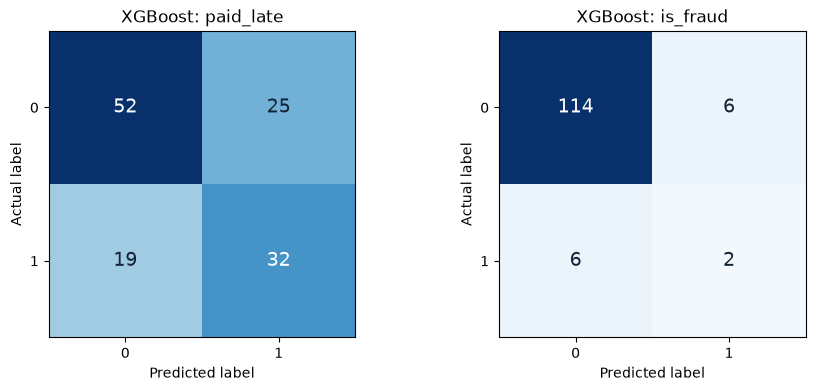

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), constrained_layout=True)
for ax, target in zip(axes, TARGETS):
    matrix = confusion_matrix(xgb_results[f"actual_{target}"], xgb_results[f"predicted_{target}"], labels=[0, 1])
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=matrix.max())
    for (i, j), count in __import__("numpy").ndenumerate(matrix):
        ax.text(j, i, str(count), ha="center", va="center", color="white" if count > matrix.max()/2 else "#142437", fontsize=14)
    ax.set(xticks=[0, 1], yticks=[0, 1], xlabel="Predicted label", ylabel="Actual label", title=f"XGBoost: {target}")
plt.show()

For fraud, the bottom-right cell is correctly flagged fraud; the bottom-left cell is missed fraud. Because the test set has only eight fraud-labelled invoices, inspect recall and precision alongside accuracy.

### 6. Load and validate the supplied SAP-RPT-1.6 Playground export

The export is kept in the repository as `exports/rpt_playground_export.csv` so this notebook is rerunnable. It has the original 1,024 labeled context rows and 128 filled test rows. The file itself does not identify the model, so the model attribution follows the supplied export's provenance.

In [8]:
rpt_export_path = DATA / "exports/rpt_playground_export.csv"
rpt_export = pd.read_csv(rpt_export_path)
assert len(rpt_export) == len(invoices) == CONTEXT_ROWS + PREDICTION_ROWS
assert rpt_export.invoice_id.is_unique
assert rpt_export.invoice_id.tolist() == invoices.invoice_id.tolist()
feature_names = [column for column in invoices.columns if column not in TARGETS]
pd.testing.assert_frame_equal(rpt_export[feature_names], invoices[feature_names], check_dtype=False)
for target in TARGETS:
    assert rpt_export[target].iloc[:CONTEXT_ROWS].tolist() == train[target].tolist()
    assert rpt_export[target].iloc[CONTEXT_ROWS:].isin([0, 1]).all()

rpt_results = pd.DataFrame({"invoice_id": test.invoice_id.to_numpy()})
rpt_rows = []
for target in TARGETS:
    actual = test[target].to_numpy()
    predicted = rpt_export[target].iloc[CONTEXT_ROWS:].to_numpy()
    rpt_results[f"actual_{target}"] = actual
    rpt_results[f"predicted_{target}"] = predicted
    rpt_rows.append({"Model": "SAP-RPT-1.6 export", "Target": target,
                     "Positive cases": int(actual.sum()),
                     "Accuracy": accuracy_score(actual, predicted),
                     "Precision": precision_score(actual, predicted, zero_division=0),
                     "Recall": recall_score(actual, predicted, zero_division=0),
                     "ROC AUC": float("nan")})
rpt_metrics = pd.DataFrame(rpt_rows).set_index(["Model", "Target"])
print(f"Validated {len(rpt_results)} test invoice IDs and all predictors against the shared source.")
display(rpt_metrics.round(3))

Validated 128 test invoice IDs and all predictors against the shared source.


Positive cases  Accuracy  Precision  Recall  \
Model              Target                                                   
SAP-RPT-1.6 export paid_late              51     0.703      0.623   0.647   
                   is_fraud                8     0.922      0.000   0.000   

                              ROC AUC  
Model              Target              
SAP-RPT-1.6 export paid_late      NaN  
                   is_fraud       NaN

### 7. Compare both models on the same 128 invoices

Accuracy shows overall correctness; recall shows how many actual positive cases each model found. RPT ROC AUC is blank because its export contains no probabilities.

In [9]:
comparison = pd.concat([xgb_metrics, rpt_metrics])
display(comparison.round(3))

agreement_rows = []
for target in TARGETS:
    actual = test[target].to_numpy()
    xgb_predicted = xgb_results[f"predicted_{target}"].to_numpy()
    rpt_predicted = rpt_results[f"predicted_{target}"].to_numpy()
    agreement_rows.append({
        "Target": target,
        "Same prediction": int((xgb_predicted == rpt_predicted).sum()),
        "Different prediction": int((xgb_predicted != rpt_predicted).sum()),
        "RPT only correct": int(((rpt_predicted == actual) & (xgb_predicted != actual)).sum()),
        "XGBoost only correct": int(((xgb_predicted == actual) & (rpt_predicted != actual)).sum()),
    })
display(pd.DataFrame(agreement_rows).set_index("Target"))

Positive cases  Accuracy  Precision  Recall  \
Model              Target                                                   
XGBoost            paid_late              51     0.656      0.561   0.627   
                   is_fraud                8     0.906      0.250   0.250   
SAP-RPT-1.6 export paid_late              51     0.703      0.623   0.647   
                   is_fraud                8     0.922      0.000   0.000   

                              ROC AUC  
Model              Target              
XGBoost            paid_late    0.724  
                   is_fraud     0.699  
SAP-RPT-1.6 export paid_late      NaN  
                   is_fraud       NaN

,Same prediction,Different prediction,RPT only correct,XGBoost only correct
Target,,,,
paid_late,110,18,12,6
is_fraud,120,8,5,3


### 8. Visual comparison

Each panel uses the same 0–100% scale. The denominators are **128 test invoices**, **51 actual late-payment cases**, and **8 actual fraud cases**. Class labels from the RPT export support accuracy, precision, and recall, but not ROC AUC.

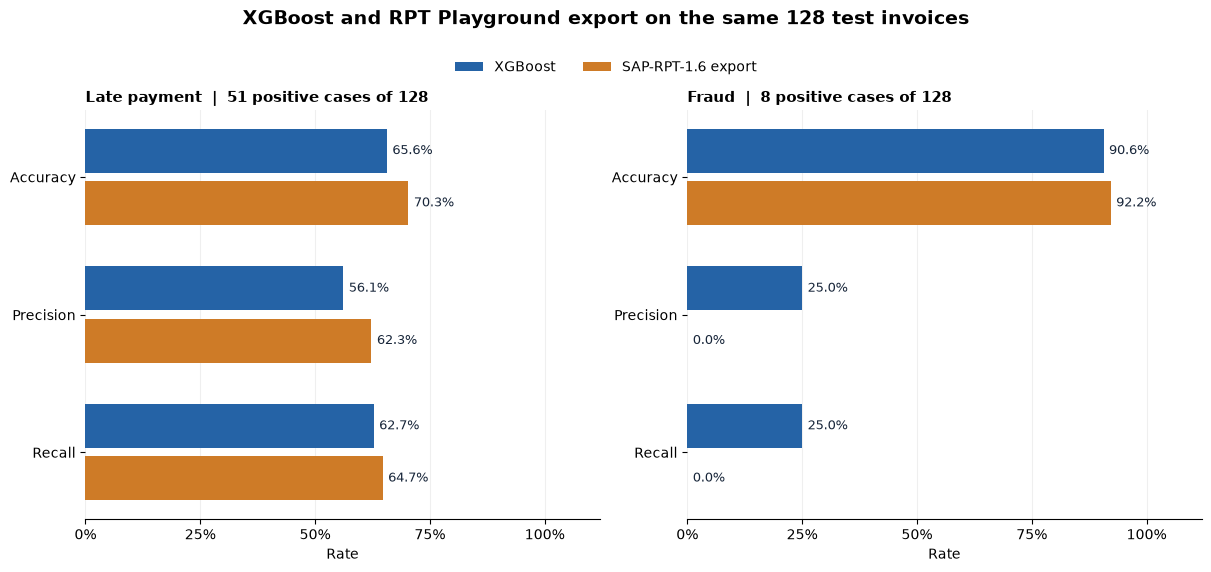

In [10]:
from matplotlib.patches import Patch

plot_metrics = ["Accuracy", "Precision", "Recall"]
model_colors = {"XGBoost": "#2563a6", "SAP-RPT-1.6 export": "#ce7b27"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, constrained_layout=True)
for ax, target, title, positives in zip(
    axes, TARGETS, ["Late payment", "Fraud"], [int(test[t].sum()) for t in TARGETS]
):
    centers = range(len(plot_metrics))
    for model, offset in [("XGBoost", -0.19), ("SAP-RPT-1.6 export", 0.19)]:
        values = [comparison.loc[(model, target), metric] * 100 for metric in plot_metrics]
        bars = ax.barh([center + offset for center in centers], values, height=0.32,
                       color=model_colors[model], label=model)
        for bar, value in zip(bars, values):
            ax.text(max(value + 1.2, 1.2), bar.get_y() + bar.get_height() / 2,
                    f"{value:.1f}%", va="center", fontsize=9, color="#18263a")
    ax.set_yticks(list(centers), plot_metrics)
    ax.invert_yaxis()
    ax.set_xlim(0, 112)
    ax.set_xticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"])
    ax.set_xlabel("Rate")
    ax.set_title(f"{title}  |  {positives} positive cases of 128", loc="left", fontsize=11, weight="bold")
    ax.xaxis.grid(True, alpha=0.2)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
fig.legend(handles=[Patch(facecolor=model_colors[name], label=name) for name in model_colors],
           loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)
fig.suptitle("XGBoost and RPT Playground export on the same 128 test invoices", y=1.16,
             fontsize=14, weight="bold")
fig.savefig(ROOT / "notebooks/model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

RPT has higher late-payment accuracy and finds one more late-payment case. Its fraud accuracy is also higher, but it finds **none** of the eight actual fraud cases. XGBoost finds two. The RPT export offers no probabilities, so the chart compares class-label metrics only.

## Takeaways

- Both models are evaluated against the **same 128 invoices** and the same two source labels.
- For **late payment**, RPT export accuracy is **70.3%** versus **65.6%** for XGBoost; RPT finds **33 of 51** positive cases versus **32 of 51** for XGBoost.
- For **fraud**, RPT export accuracy is **92.2%** versus **90.6%** for XGBoost, but RPT finds **0 of 8** positive cases versus **2 of 8** for XGBoost. Fraud recall is more informative than accuracy alone here.
- The models agree on **110 of 128** late-payment predictions and **120 of 128** fraud predictions.
- The RPT class labels came from the supplied Playground table export, which does not itself include model metadata or probabilities. RPT ROC AUC is unavailable from this file.
- These synthetic results demonstrate the experiment workflow; they cannot validate a real payment or fraud decision system.